# Object segmentation network

## Table of Contents

### Import libraries


In [2]:
from torch.utils.data import Dataset
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches


<a id="Initialize-the-data-loader"></a>
### Data loader implementation

In [3]:
from model_utils import *

### Initialize the data loader

In [4]:
train_dataset, test_dataset = prepare_dataset()
# Create a DataLoader to iterate through the dataset
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

macOS


### Test the data loader
(re-run this cell to see different examples)

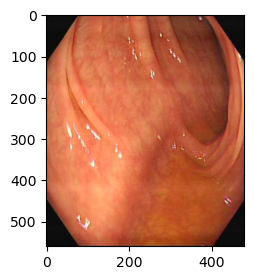

tensor([[336., 163., 426., 227.]])


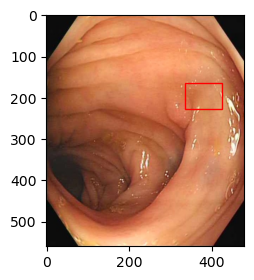

tensor([[240., 276., 325., 339.]])


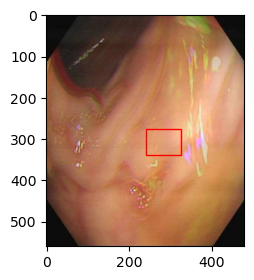

tensor([[216., 319., 291., 403.]])


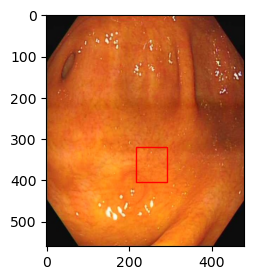

tensor([[142.,  92., 345., 159.]])


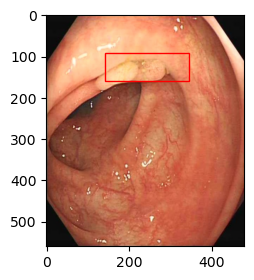

In [5]:
max_images_to_display = 5  # Set the maximum number of images to display
image_counter = 0    # Initialize a counter

# Set the desired figure size
fig_width, fig_height = 4, 3  # Adjust these values to your preference

# Test by iterating through the dataset
for image, target in train_dataloader:
    # Convert the PyTorch tensor to a NumPy array for visualization
    image = image.squeeze(0).permute(1, 2, 0).numpy()

    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(fig_width, fig_height))
    ax.imshow(image)
    
    bounding_boxes = target['boxes']
    # Iterate through bounding boxes and draw them on the image
    if bounding_boxes.numel() > 0:
        for box in bounding_boxes:
            print(box)
            box = box.squeeze(0) # flatten the tensor to avoid unpacking error
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    # Show the image with bounding boxes
    plt.show()
    
    # Increment the image counter
    image_counter += 1

    if image_counter >= max_images_to_display:
        break  # Exit the loop after displaying the desired number of images

### Select the device to train the model on 
(GPU by default if available)

In [6]:
import torch

# Enable MPS fallback
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Check if CUDA is available, which it will be on most Windows/Linux machines with NVIDIA GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


### Define the data collate function for the DataLoader
(which combines multiple images into a batch)

### Define the model

In [7]:
from model_utils import *
# Define hyperparameters
param = {
    "BATCH_SIZE":  2,
    "LR" : 0.005,
    "WEIGHT_DECAY": 0.0005,
    "CONFIDENCE_THRESHOLD": 0.5
}


In [8]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=param["BATCH_SIZE"], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=param["BATCH_SIZE"], collate_fn=collate_fn)


In [9]:
# Modify the model for your specific dataset: Change the number of classes
# num_classes = 1 # 1 class (Polyp) + background
num_classes = 2  # 1 class (polyp) + 1 background
model = get_model('FasterRCNN', num_classes)

# Define the optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=param["LR"], momentum=0.9, weight_decay=param["WEIGHT_DECAY"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Define the loss function
criterion = torch.nn.CrossEntropyLoss()

model = model.to(device)
print("Classes in the model's classifier:", model.roi_heads.box_predictor.cls_score.out_features)

/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Classes in the model's classifier: 2


### Test the training of the model to see if it works 

In [10]:
# For Training
images, targets = next(iter(train_loader))
images = [image.to(device) for image in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]  # Move targets to the device

output = model(images, targets)  # Returns losses and detections
print(output)

{'loss_classifier': tensor(0.6604, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0888, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0079, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0049, grad_fn=<DivBackward0>)}


{'boxes': tensor([[3.0396e+02, 0.0000e+00, 4.7727e+02, 3.2282e+02],
        [0.0000e+00, 1.6095e+01, 3.8068e+02, 2.3812e+02],
        [2.4978e+02, 0.0000e+00, 4.4582e+02, 2.3896e+02],
        [4.2260e+02, 7.7122e+00, 4.7958e+02, 3.6134e+02],
        [4.1727e+02, 4.7444e+01, 4.7215e+02, 2.3835e+02],
        [7.1775e+00, 0.0000e+00, 4.5283e+02, 4.0980e+02],
        [4.2444e+02, 0.0000e+00, 4.7590e+02, 4.7049e+01],
        [4.4723e+02, 9.0449e+01, 4.7578e+02, 1.8738e+02],
        [4.4910e+02, 4.2836e+02, 4.6549e+02, 4.5029e+02],
        [4.6858e+02, 1.1272e+02, 4.7965e+02, 1.2560e+02],
        [3.5528e+02, 0.0000e+00, 4.7647e+02, 2.2990e+02],
        [4.6120e+02, 8.6058e+01, 4.7997e+02, 1.8768e+02],
        [6.8694e+00, 0.0000e+00, 4.7695e+02, 1.1570e+02],
        [4.4338e+02, 1.2607e+02, 4.7884e+02, 1.7361e+02],
        [4.6856e+02, 1.1768e+02, 4.7962e+02, 1.2992e+02],
        [4.0453e+02, 8.5926e+01, 4.7572e+02, 1.9296e+02],
        [0.0000e+00, 0.0000e+00, 1.5743e+02, 8.8864e+01],
    

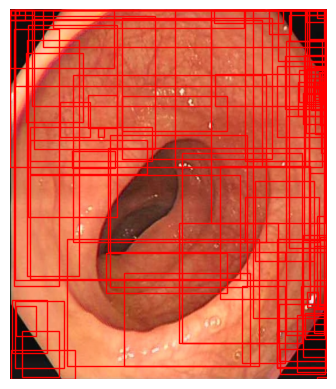

In [12]:
# For inference
model.eval()

# Get a batch of images from the DataLoader
images, targets = next(iter(train_loader))

# Select the first image from the batch for inference
# Assuming your DataLoader returns a batch of images and targets
image_to_infer = images[0].unsqueeze(0).to(device)  # Add batch dimension and move to the device

# Disable gradient computation since we're only doing inference
with torch.no_grad():
    # Perform inference
    predictions = model(image_to_infer)  # Returns predictions

    # Print out the predictions for the first image
    print(predictions[0])
    
# Process the first image and its prediction
image = image_to_infer[0].cpu().numpy()  # Move the tensor to cpu and convert to numpy
image = np.transpose(image, (1, 2, 0))  # Transpose from CxHxW to HxWxC for matplotlib

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis

# Add the predicted bounding boxes
for box in predictions[0]['boxes']:
    xmin, ymin, xmax, ymax = box.cpu().numpy()
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=1, edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

### Train the model

In [13]:
num_epochs = 2
model, epoch_losses, batch_losses, epoch = train_model(train_dataset, param, num_epochs, device, model_s='FasterRCNN')


Classes in the model's classifier: 2
epoch: 1
batch: 1


KeyboardInterrupt: 

In [ ]:
# num_epochs = 2
# model, epoch_losses, batch_losses, epoch = train_model(train_dataset, param, num_epochs, device, model_s='SSD')


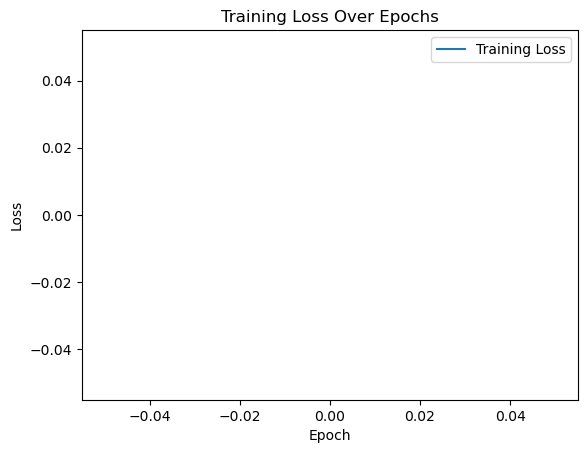

In [24]:
# After training, you can plot the epoch losses
plt.plot(epoch_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

### Saving the model

In [ ]:
save_model_with_hyperparams(model,'FasterRCNN',params,epoch_losses,batch_losses,epoch)

Evaluate model

In [25]:
from torchvision.ops import box_iou

# Usage:
metrics = evaluate(model, val_loader, device, params["CONFIDENCE_THRESHOLD"])
print(f"Precision: {metrics['precision']}")
print(f"Recall: {metrics['recall']}")
print(f"F1 Score: {metrics['f1']}")
print(f"Average IoU: {sum(metrics['ious']) / len(metrics['ious']) if metrics['ious'] else 0}")


KeyboardInterrupt: 

## Data augmentation

### Data analysis

#### Bounding box analysis

In [45]:
from data_utils import *

# This can take a while to run!
# Assuming train_dataset is an instance of CustomDataset
all_bounding_boxes = get_all_bounding_boxes(train_dataset)
print("Number of bounding boxes:", len(all_bounding_boxes))

Number of bounding boxes: 14349


Elbow method to determine ideal number of clusters

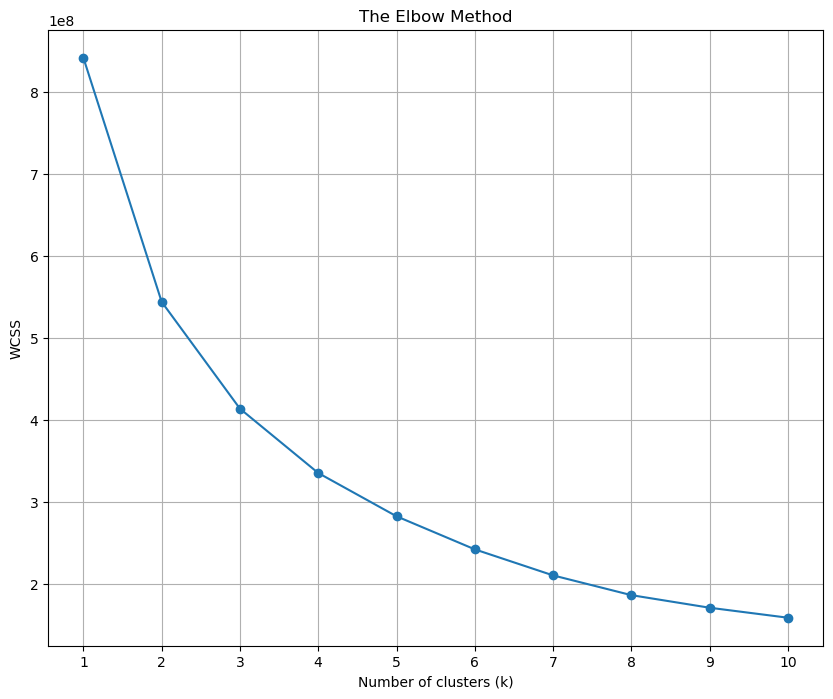

In [46]:
# Calculate WCSS for a range of number of clusters
wcss = calculate_wcss(all_bounding_boxes, max_k=10)
plot_elbow(wcss)

Silhouette score to determine ideal number of clusters (higher is better)

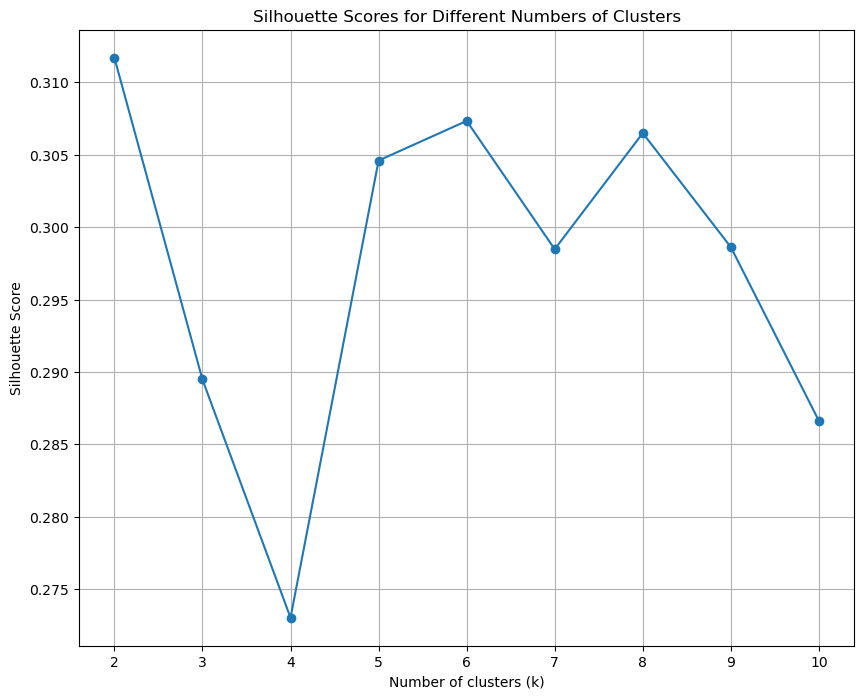

In [47]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for a range of number of clusters
silhouette_scores = calculate_silhouette_scores(all_bounding_boxes, max_k=10)
plot_silhouette_scores(silhouette_scores)

In [48]:
# Use the function with your data
centers_8, labels_8 = cluster_bounding_boxes(all_bounding_boxes,8)
centers_3, labels_3 = cluster_bounding_boxes(all_bounding_boxes,3)
print("Cluster Centers:", centers_8)

/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/pol/anaconda3/envs/TFG/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster Centers: [[242.81146  342.69122  100.99544   69.126656]
 [385.93372  273.7093    70.95773   72.08136 ]
 [151.67966   58.3228   333.57034  377.53748 ]
 [402.57465  100.86489   73.1887    86.783806]
 [243.75182  179.94199  125.231926 121.00835 ]
 [ 65.3938    98.53368  214.2414   207.17905 ]
 [127.78538   85.32345   73.772896  66.784134]
 [ 93.18037  265.82077   88.01547   95.42024 ]]


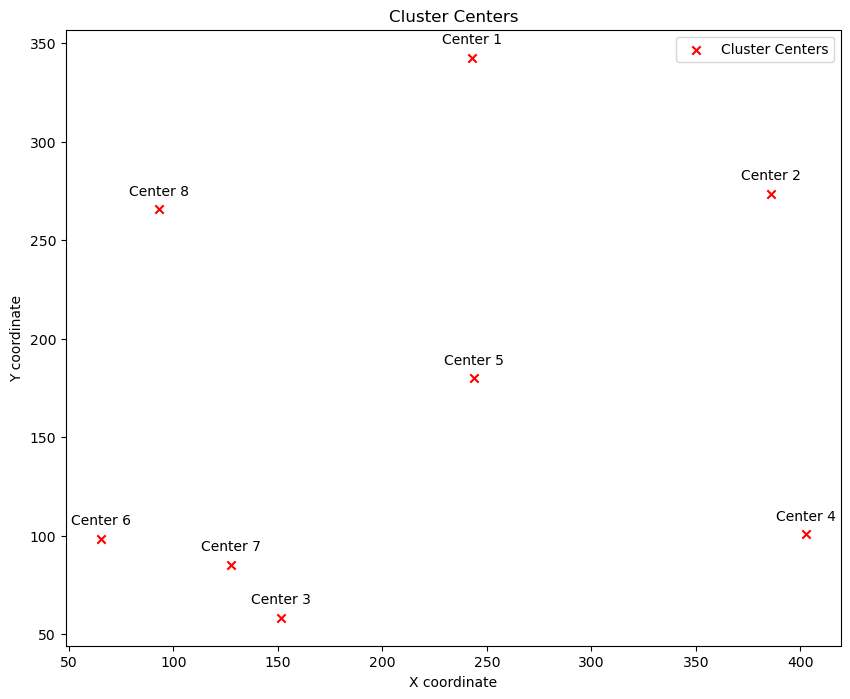

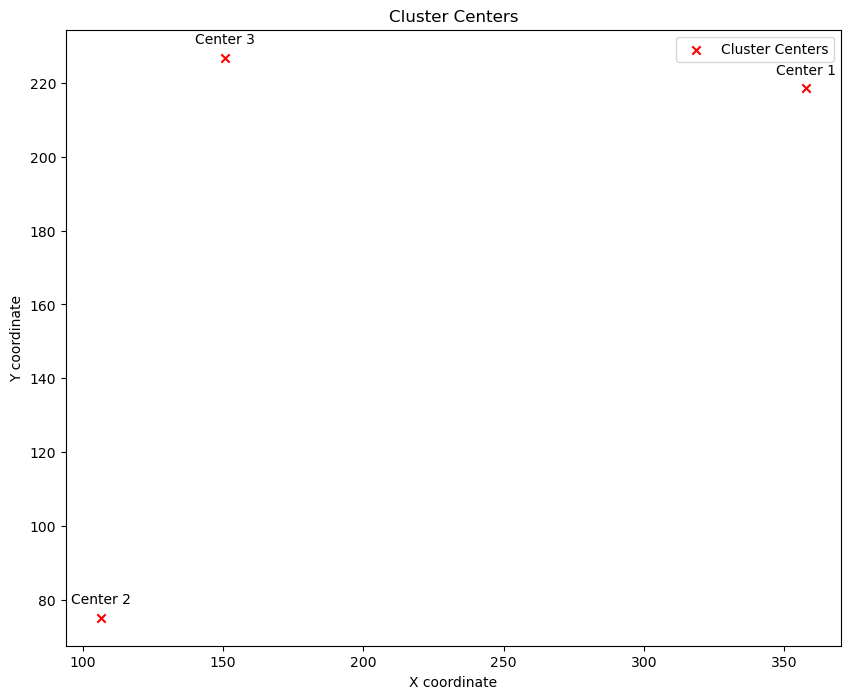

In [49]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
plot_cluster_centers(centers_8)
plot_cluster_centers(centers_3)


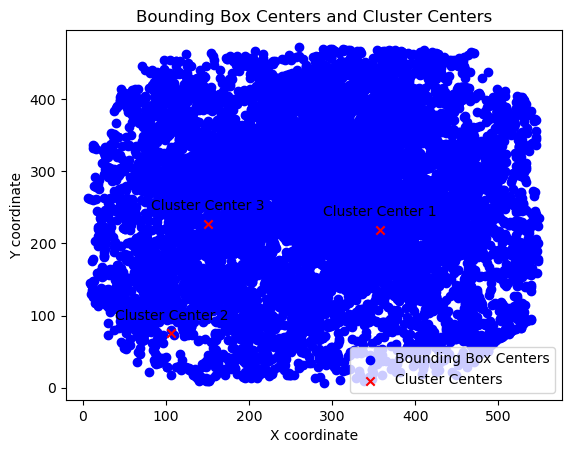

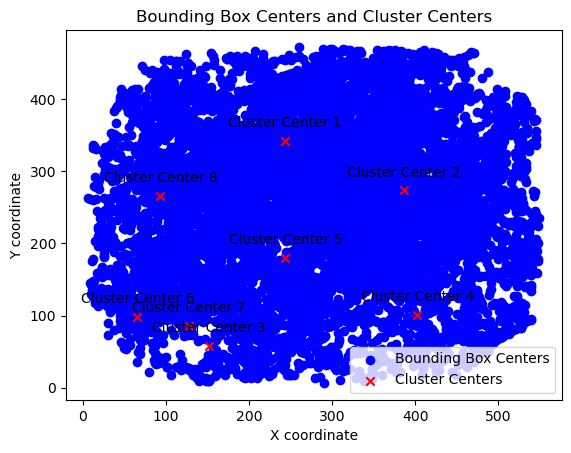

In [50]:
# Example usage
# Assume that `centers` contains the cluster centers calculated from your bounding boxes.
# Also, assume that `bounding_boxes` contains your bounding box data.
plot_cluster_centers_with_bbox_centers(centers_3, all_bounding_boxes)
plot_cluster_centers_with_bbox_centers(centers_8, all_bounding_boxes)

